In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

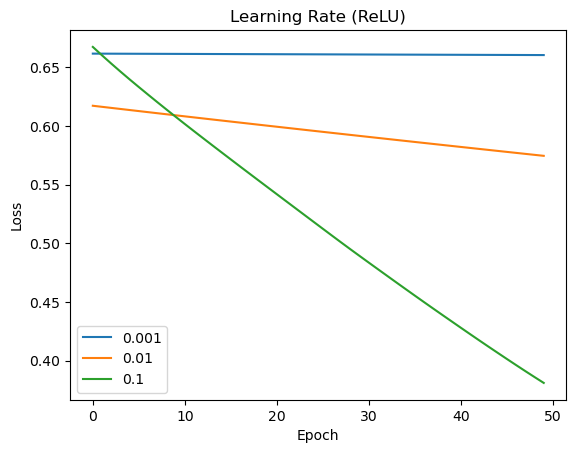

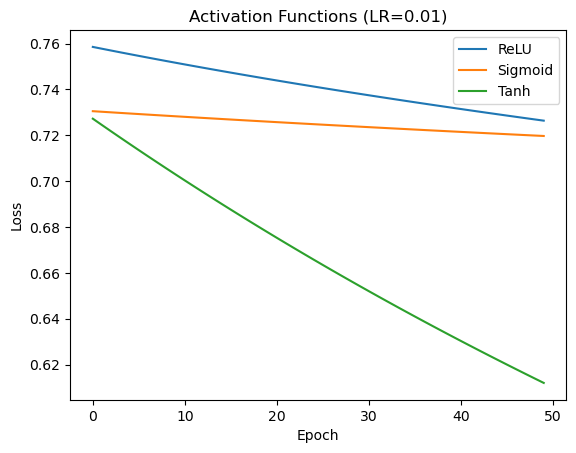

In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

# Data (UNCHANGED)
torch.manual_seed(42)
X = torch.randn(200, 2)
y = (X[:, 0] + X[:, 1] > 0).float().view(-1, 1)

# Model (just cleaner)
class NN(nn.Module):
    def __init__(self, act):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, 8),
            act,
            nn.Linear(8, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.net(x)

# Train
def train(lr, act):
    model = NN(act)
    opt = optim.SGD(model.parameters(), lr=lr)
    loss_fn = nn.BCELoss()

    losses = []
    for _ in range(50):
        opt.zero_grad()
        loss = loss_fn(model(X), y)
        loss.backward()
        opt.step()
        losses.append(loss.item())
    return losses

# ---- Learning Rates ----
for lr in [0.001, 0.01, 0.1]:
    plt.plot(train(lr, nn.ReLU()), label=f"{lr}")

plt.title("Learning Rate (ReLU)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

# ---- Activations ----
for name, act in [("ReLU", nn.ReLU()), ("Sigmoid", nn.Sigmoid()), ("Tanh", nn.Tanh())]:
    plt.plot(train(0.01, act), label=name)

plt.title("Activation Functions (LR=0.01)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()